# Klasifikasi Sampah: Organik, Anorganik, Residu (Improved v2)

Notebook ini melakukan klasifikasi gambar sampah ke dalam 3 kategori:
- **Organik**: Sampah yang dapat terurai secara alami (dari dataset arthurwaruwu/datasetcapstonefixx)
- **Anorganik**: Sampah yang dapat didaur ulang / Recyclable (dari dataset phenomsg/waste-classification)
- **Residu**: Sampah yang tidak dapat didaur ulang / Non-Recyclable (dari dataset phenomsg/waste-classification)

**Perbaikan dari v1:**
- Hybrid Balancing (bukan pure undersampling) → lebih banyak data training
- EfficientNetB0 (menggantikan MobileNetV2) → akurasi lebih tinggi
- MixUp Augmentation → regularisasi lebih baik
- Label Smoothing → mengurangi overconfidence
- Class Weights → menangani sisa imbalance
- Test-Time Augmentation (TTA) → evaluasi lebih robust
- Augmentasi lebih agresif → generalisasi lebih baik

## 1. Install & Import Libraries

In [97]:
# Install dependencies (uncomment jika belum terinstall)
!pip install kaggle tensorflow matplotlib scikit-learn seaborn Pillow pandas


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import os
import shutil
import zipfile
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## 2. Download Dataset dari Kaggle

Pastikan file `kaggle.json` sudah dikonfigurasi:
- Letakkan di `~/.kaggle/kaggle.json` (Linux/Mac) atau `C:\Users\<username>\.kaggle\kaggle.json` (Windows)
- Dapatkan dari https://www.kaggle.com/settings -> "Create New Token"

In [99]:
# Konfigurasi path
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "datasets"
ORGANIK_ZIP = DATA_DIR / "organik.zip"
WASTE_CLASS_ZIP = DATA_DIR / "waste_classification.zip"
ORGANIK_EXTRACT = DATA_DIR / "organik_raw"
WASTE_EXTRACT = DATA_DIR / "waste_raw"

# Buat direktori
DATA_DIR.mkdir(parents=True, exist_ok=True)
ORGANIK_EXTRACT.mkdir(parents=True, exist_ok=True)
WASTE_EXTRACT.mkdir(parents=True, exist_ok=True)

In [100]:
# Download dataset Organik (arthurwaruwu/datasetcapstonefixx)
# Skip jika folder extract sudah ada ATAU zip sudah ada
if ORGANIK_EXTRACT.exists() and any(ORGANIK_EXTRACT.iterdir()):
    print("Dataset Organik sudah ter-extract, skip download & extract.")
elif not ORGANIK_ZIP.exists():
    print("Downloading dataset Organik...")
    os.system(f'kaggle datasets download -d arthurwaruwu/datasetcapstonefixx -p "{DATA_DIR}" --force')
    # Rename file hasil download
    downloaded = list(DATA_DIR.glob("datasetcapstonefixx*"))
    if downloaded:
        downloaded[0].rename(ORGANIK_ZIP)
    print("Download Organik selesai!")
else:
    print("ZIP Organik sudah ada, skip download.")

Dataset Organik sudah ter-extract, skip download & extract.


In [101]:
# Download dataset Waste Classification (phenomsg/waste-classification)
# Skip jika folder extract sudah ada ATAU zip sudah ada
if WASTE_EXTRACT.exists() and any(WASTE_EXTRACT.iterdir()):
    print("Dataset Waste Classification sudah ter-extract, skip download & extract.")
elif not WASTE_CLASS_ZIP.exists():
    print("Downloading dataset Waste Classification...")
    os.system(f'kaggle datasets download -d phenomsg/waste-classification -p "{DATA_DIR}" --force')
    # Rename file hasil download
    downloaded = list(DATA_DIR.glob("waste-classification*"))
    if downloaded:
        downloaded[0].rename(WASTE_CLASS_ZIP)
    print("Download Waste Classification selesai!")
else:
    print("ZIP Waste Classification sudah ada, skip download.")

Dataset Waste Classification sudah ter-extract, skip download & extract.


## 3. Extract Dataset

In [102]:
def extract_zip(zip_path, extract_to):
    """Extract zip file ke folder tujuan."""
    if not any(extract_to.iterdir()):
        print(f"Extracting {zip_path.name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Extraction selesai: {extract_to}")
    else:
        print(f"Folder {extract_to} sudah berisi data, skip extraction.")

extract_zip(ORGANIK_ZIP, ORGANIK_EXTRACT)
extract_zip(WASTE_CLASS_ZIP, WASTE_EXTRACT)

Folder datasets\organik_raw sudah berisi data, skip extraction.
Folder datasets\waste_raw sudah berisi data, skip extraction.


In [103]:
# Lihat struktur folder hasil extract
def show_tree(path, prefix="", max_depth=3, current_depth=0):
    """Tampilkan struktur folder."""
    if current_depth >= max_depth:
        return
    entries = sorted(Path(path).iterdir())
    dirs = [e for e in entries if e.is_dir()]
    files = [e for e in entries if e.is_file()]

    if files:
        print(f"{prefix}[{len(files)} files]")
    for d in dirs:
        print(f"{prefix}📁 {d.name}/")
        show_tree(d, prefix + "  ", max_depth, current_depth + 1)

print("=== Struktur Dataset Organik ===")
show_tree(ORGANIK_EXTRACT)
print("\n=== Struktur Dataset Waste Classification ===")
show_tree(WASTE_EXTRACT)

=== Struktur Dataset Organik ===
📁 Dataset-Asli/
  📁 Anorganik/
    📁 Elektronik/
    📁 Kaca/
    📁 Kain/
    📁 Kardus/
    📁 Karet/
    📁 Kertas/
    📁 Logam/
    📁 Plastik/
    📁 Sepatu/
    📁 Styrofoam/
  📁 Organik/
    📁 Cangkang Telur/
    📁 Kayu/
    📁 Kotoran Hewan/
    📁 Sisa Buah/
    📁 Sisa makanan/
    📁 Sisa Teh Kopi/
    📁 Tumbuhan/

=== Struktur Dataset Waste Classification ===
📁 Hazardous/
  📁 Hazardous/
    📁 batteries/
    📁 e-waste/
    📁 paints/
    📁 pesticides/
📁 Non-Recyclable/
  📁 Non-Recyclable/
    📁 ceramic_product/
    📁 diapers/
    📁 platics_bags_wrappers/
    📁 sanitary_napkin/
    📁 stroform_product/
📁 Organic/
  📁 Organic/
    📁 coffee_tea_bags/
    📁 egg_shells/
    📁 food_scraps/
    📁 kitchen_waste/
    📁 yard_trimmings/
📁 Recyclable/
  📁 Recyclable/
    📁 cans_all_type/
    📁 glass_containers/
    📁 paper_products/
    📁 plastic_bottles/


## 4. Pengumpulan & Validasi Gambar

Mapping:
- **Organik** ← Semua gambar dari dataset arthurwaruwu/datasetcapstonefixx
- **Anorganik** ← Folder `Recyclable/` dari phenomsg/waste-classification
- **Residu** ← Folder `Non-Recyclable/` dari phenomsg/waste-classification

In [104]:
# Cari folder sumber secara otomatis
def find_image_dirs(base_path, target_names):
    """Cari folder berdasarkan nama di dalam base_path."""
    found = {}
    for root, dirs, files in os.walk(base_path):
        for d in dirs:
            d_lower = d.lower().replace("-", "").replace("_", "").replace(" ", "")
            for target in target_names:
                t_lower = target.lower().replace("-", "").replace("_", "").replace(" ", "")
                if d_lower == t_lower:
                    found[target] = Path(root) / d
    return found

# Cari folder Recyclable dan Non-Recyclable
waste_dirs = find_image_dirs(WASTE_EXTRACT, ["Recyclable", "Non-Recyclable"])
print("Folder ditemukan di waste dataset:")
for k, v in waste_dirs.items():
    print(f"  {k}: {v}")

Folder ditemukan di waste dataset:
  Non-Recyclable: datasets\waste_raw\Non-Recyclable\Non-Recyclable
  Recyclable: datasets\waste_raw\Recyclable\Recyclable


In [105]:
# Fungsi untuk mengumpulkan path gambar dari folder (termasuk subfolder)
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

def collect_image_paths(folder_path):
    """Kumpulkan semua path gambar valid dari folder dan subfoldernya."""
    paths = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if Path(f).suffix.lower() in VALID_EXTENSIONS:
                paths.append(str(Path(root) / f))
    return paths

def validate_image(img_path):
    """Validasi apakah file gambar bisa dibuka dan tidak corrupt."""
    try:
        with Image.open(img_path) as img:
            img.verify()
        return True
    except Exception:
        return False

def validate_images_batch(image_list, label=""):
    """Validasi batch gambar dan kembalikan hanya yang valid."""
    valid = []
    invalid_count = 0
    for i, img_path in enumerate(image_list):
        if validate_image(img_path):
            valid.append(img_path)
        else:
            invalid_count += 1
        if (i + 1) % 1000 == 0:
            print(f"  [{label}] Validasi {i+1}/{len(image_list)}...")
    if invalid_count > 0:
        print(f"  [{label}] {invalid_count} gambar corrupt/invalid dibuang.")
    else:
        print(f"  [{label}] Semua {len(valid)} gambar valid.")
    return valid

In [106]:
# Kumpulkan gambar per kategori
organik_images = collect_image_paths(ORGANIK_EXTRACT)
print(f"Jumlah gambar Organik (raw): {len(organik_images)}")

anorganik_images = []
if "Recyclable" in waste_dirs:
    anorganik_images = collect_image_paths(waste_dirs["Recyclable"])
print(f"Jumlah gambar Anorganik (raw): {len(anorganik_images)}")

residu_images = []
if "Non-Recyclable" in waste_dirs:
    residu_images = collect_image_paths(waste_dirs["Non-Recyclable"])
print(f"Jumlah gambar Residu (raw): {len(residu_images)}")

Jumlah gambar Organik (raw): 10381
Jumlah gambar Anorganik (raw): 662
Jumlah gambar Residu (raw): 647


In [107]:
# Validasi gambar — buang yang corrupt
print("\nValidasi gambar...")
organik_valid = validate_images_batch(organik_images, "Organik")
anorganik_valid = validate_images_batch(anorganik_images, "Anorganik")
residu_valid = validate_images_batch(residu_images, "Residu")

print(f"\nSetelah validasi:")
print(f"  Organik:   {len(organik_valid)}")
print(f"  Anorganik: {len(anorganik_valid)}")
print(f"  Residu:    {len(residu_valid)}")


Validasi gambar...
  [Organik] Validasi 1000/10381...
  [Organik] Validasi 2000/10381...
  [Organik] Validasi 3000/10381...
  [Organik] Validasi 4000/10381...
  [Organik] Validasi 5000/10381...
  [Organik] Validasi 6000/10381...
  [Organik] Validasi 7000/10381...
  [Organik] Validasi 8000/10381...
  [Organik] Validasi 9000/10381...
  [Organik] Validasi 10000/10381...
  [Organik] Semua 10381 gambar valid.
  [Anorganik] Semua 662 gambar valid.
  [Residu] Semua 647 gambar valid.

Setelah validasi:
  Organik:   10381
  Anorganik: 662
  Residu:    647


## 5. Visualisasi Distribusi Awal

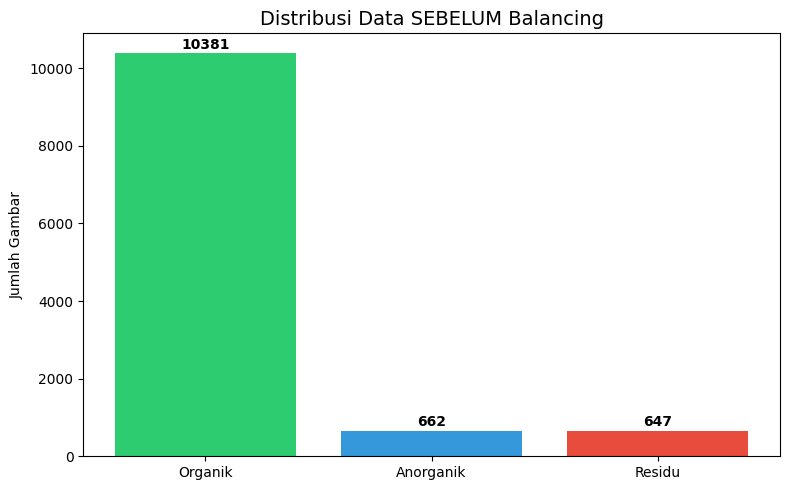

In [108]:
categories = ['Organik', 'Anorganik', 'Residu']
counts_raw = [len(organik_valid), len(anorganik_valid), len(residu_valid)]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts_raw, color=['#2ecc71', '#3498db', '#e74c3c'])
for bar, count in zip(bars, counts_raw):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'{count}', ha='center', va='bottom', fontweight='bold')
plt.title('Distribusi Data SEBELUM Balancing', fontsize=14)
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.savefig('distribusi_sebelum_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hybrid Balancing

**Strategi baru (v2):**
- Organik di-downsample ke ~2000 (bukan ke 647 seperti v1)
- Anorganik & Residu **tetap semua** (662 & 647)
- Sisa imbalance ditangani oleh `class_weight` saat training
- Total data: ~3300 (vs ~1941 di v1) → 70% lebih banyak data training

In [109]:
# Hybrid Balancing: downsample Organik ke 2000, keep all Anorganik & Residu
TARGET_ORGANIK = 2000

random.seed(SEED)
if len(organik_valid) > TARGET_ORGANIK:
    organik_balanced = random.sample(organik_valid, TARGET_ORGANIK)
    print(f"Organik di-downsample dari {len(organik_valid)} → {TARGET_ORGANIK}")
else:
    organik_balanced = organik_valid
    print(f"Organik tetap {len(organik_valid)} (sudah <= {TARGET_ORGANIK})")

anorganik_balanced = anorganik_valid  # Keep ALL
residu_balanced = residu_valid        # Keep ALL

print(f"\nSetelah Hybrid Balancing:")
print(f"  Organik:   {len(organik_balanced)}")
print(f"  Anorganik: {len(anorganik_balanced)}")
print(f"  Residu:    {len(residu_balanced)}")
total = len(organik_balanced) + len(anorganik_balanced) + len(residu_balanced)
print(f"  TOTAL:     {total}")

Organik di-downsample dari 10381 → 2000

Setelah Hybrid Balancing:
  Organik:   2000
  Anorganik: 662
  Residu:    647
  TOTAL:     3309


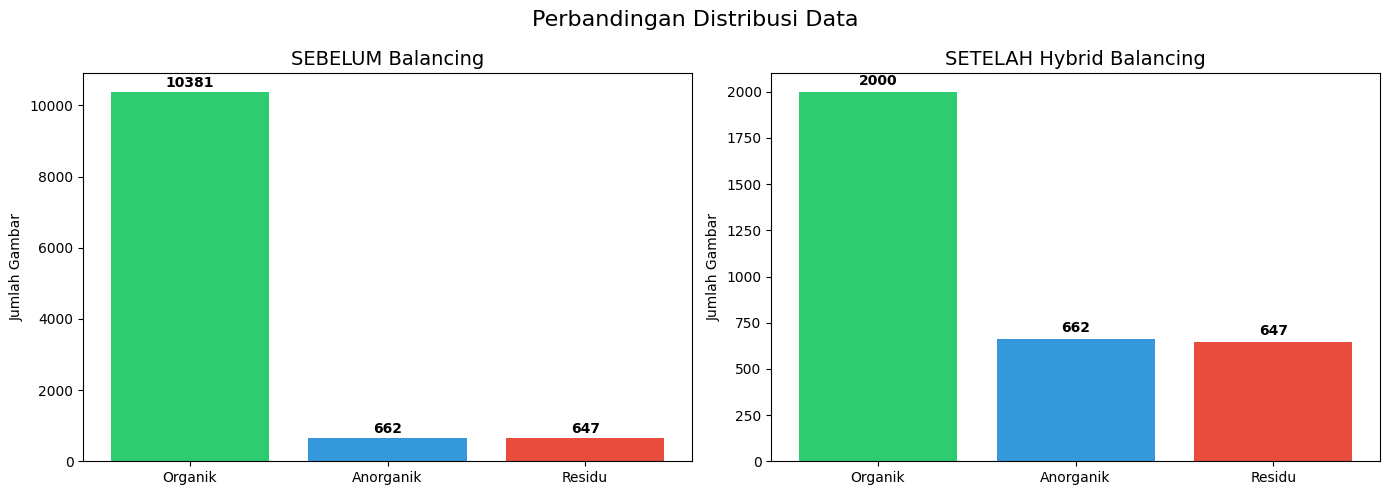

In [110]:
# Visualisasi distribusi setelah balancing
counts_balanced = [len(organik_balanced), len(anorganik_balanced), len(residu_balanced)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(categories, counts_raw, color=['#2ecc71', '#3498db', '#e74c3c'])
for i, count in enumerate(counts_raw):
    ax1.text(i, count + 50, f'{count}', ha='center', va='bottom', fontweight='bold')
ax1.set_title('SEBELUM Balancing', fontsize=14)
ax1.set_ylabel('Jumlah Gambar')

ax2.bar(categories, counts_balanced, color=['#2ecc71', '#3498db', '#e74c3c'])
for i, count in enumerate(counts_balanced):
    ax2.text(i, count + 20, f'{count}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('SETELAH Hybrid Balancing', fontsize=14)
ax2.set_ylabel('Jumlah Gambar')

plt.suptitle('Perbandingan Distribusi Data', fontsize=16)
plt.tight_layout()
plt.savefig('distribusi_setelah_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Membuat DataFrame & Split Data (70/15/15)

In [111]:
# Buat DataFrame dari semua gambar yang sudah di-balance
df_all = pd.DataFrame({
    'filename': organik_balanced + anorganik_balanced + residu_balanced,
    'class': (['Organik'] * len(organik_balanced) +
              ['Anorganik'] * len(anorganik_balanced) +
              ['Residu'] * len(residu_balanced))
})

# Shuffle
df_all = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total gambar: {len(df_all)}")
print(df_all['class'].value_counts())

Total gambar: 3309
class
Organik      2000
Anorganik     662
Residu        647
Name: count, dtype: int64


In [112]:
# Split: Train 70%, Val 15%, Test 15%
train_df, temp_df = train_test_split(
    df_all, test_size=0.30, stratify=df_all['class'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['class'], random_state=SEED
)

print(f"\nJumlah Train: {len(train_df)}")
print(train_df['class'].value_counts())
print(f"\nJumlah Validation: {len(val_df)}")
print(val_df['class'].value_counts())
print(f"\nJumlah Test: {len(test_df)}")
print(test_df['class'].value_counts())


Jumlah Train: 2316
class
Organik      1400
Anorganik     463
Residu        453
Name: count, dtype: int64

Jumlah Validation: 496
class
Organik      300
Anorganik     99
Residu        97
Name: count, dtype: int64

Jumlah Test: 497
class
Organik      300
Anorganik    100
Residu        97
Name: count, dtype: int64


## 8. Visualisasi Sample Gambar

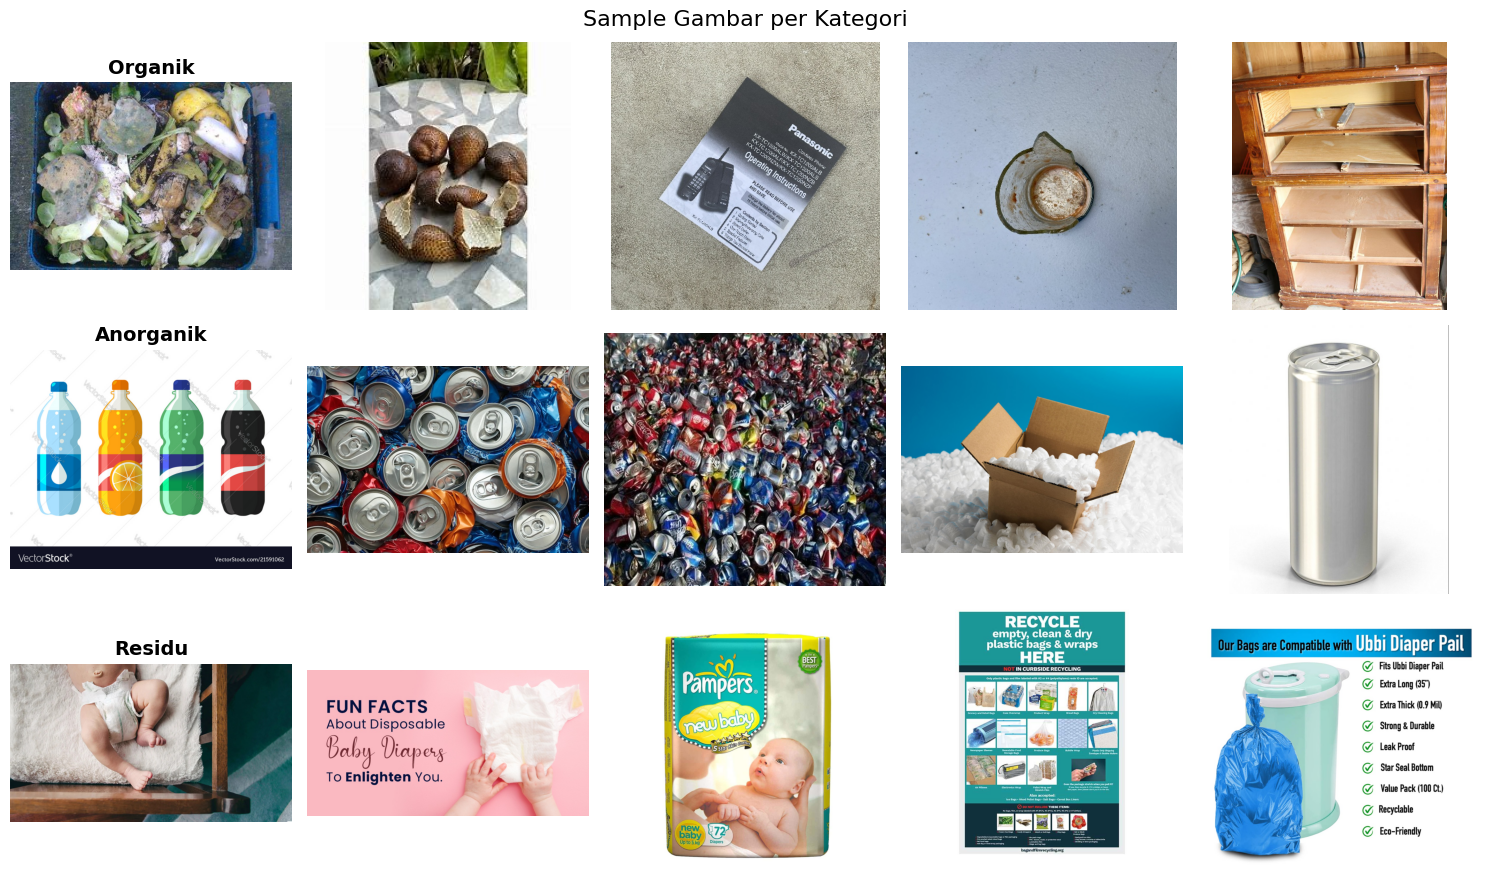

In [113]:
def show_sample_images(dataframe, n_samples=5):
    """Tampilkan sample gambar dari setiap kategori."""
    fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

    for row, category in enumerate(categories):
        cat_images = dataframe[dataframe['class'] == category]['filename'].values[:n_samples]

        for col, img_path in enumerate(cat_images):
            try:
                img = Image.open(img_path).convert('RGB')
                axes[row, col].imshow(img)
            except Exception:
                axes[row, col].text(0.5, 0.5, 'Error', ha='center', va='center')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_title(category, fontsize=14, fontweight='bold')

    plt.suptitle('Sample Gambar per Kategori', fontsize=16)
    plt.tight_layout()
    plt.savefig('sample_gambar.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_images(train_df)

## 9. Data Generator dengan Augmentasi Agresif

In [114]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentasi AGRESIF untuk training (v2 — jauh lebih kuat dari v1)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,          # v1: 30
    width_shift_range=0.3,      # v1: 0.2
    height_shift_range=0.3,     # v1: 0.2
    shear_range=0.3,            # v1: 0.2
    zoom_range=0.3,             # v1: 0.2
    horizontal_flip=True,
    vertical_flip=True,         # BARU: sampah bisa posisi apa aja
    brightness_range=[0.6, 1.4],  # v1: [0.8, 1.2]
    channel_shift_range=30.0,   # BARU: variasi warna
    fill_mode='nearest'
)

# Validasi & Test hanya rescale (tanpa augmentasi)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [115]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=False
)

Found 2299 validated image filenames belonging to 3 classes.
Found 495 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 17 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


Found 494 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [116]:
# Tampilkan class mapping
print("Class indices:", train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print("Class names:", class_names)
print(f"\nTrain samples: {train_generator.samples}")
print(f"Val samples:   {val_generator.samples}")
print(f"Test samples:  {test_generator.samples}")

Class indices: {'Organik': 0, 'Anorganik': 1, 'Residu': 2}
Class names: ['Organik', 'Anorganik', 'Residu']

Train samples: 2299
Val samples:   495
Test samples:  494


## 10. Hitung Class Weights

Karena data masih imbalance (Organik ~2000 vs Anorganik ~662 vs Residu ~647),
kita gunakan `class_weight` agar model tidak bias ke kelas mayoritas.

In [117]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array(categories),
    y=train_df['class'].values
)

class_weights_dict = {}
for cls_name, weight in zip(categories, class_weights_array):
    idx = train_generator.class_indices[cls_name]
    class_weights_dict[idx] = weight

print("Class Weights:")
for cls_name, weight in zip(categories, class_weights_array):
    print(f"  {cls_name}: {weight:.4f}")

Class Weights:
  Organik: 0.5514
  Anorganik: 1.6674
  Residu: 1.7042


## 11. MixUp Generator

MixUp: mencampurkan 2 gambar dan label-nya secara linear.
Ini membantu model belajar decision boundary yang lebih smooth dan mengurangi overfitting.

In [118]:
def mixup_generator(generator, alpha=0.2, class_weights=None):
    """Wrapper generator yang mengaplikasikan MixUp augmentation.
    
    class_weights: dict {class_idx: weight} — diintegrasikan sebagai sample_weight
    karena Keras tidak mendukung class_weight dengan Python generator.
    """
    # Buat array weights berdasarkan jumlah kelas
    if class_weights is not None:
        num_classes = len(class_weights)
        weight_array = np.array([class_weights[i] for i in range(num_classes)])
    
    while True:
        X1, y1 = next(generator)
        X2, y2 = next(generator)

        # Samakan ukuran batch
        batch_size = min(X1.shape[0], X2.shape[0])
        if batch_size == 0:
            continue

        X1, y1 = X1[:batch_size], y1[:batch_size]
        X2, y2 = X2[:batch_size], y2[:batch_size]

        # Lambda dari distribusi Beta
        lam = np.random.beta(alpha, alpha, batch_size)
        X_lam = lam.reshape(batch_size, 1, 1, 1)
        y_lam = lam.reshape(batch_size, 1)

        # Campurkan gambar dan label
        X_mix = X1 * X_lam + X2 * (1 - X_lam)
        y_mix = y1 * y_lam + y2 * (1 - y_lam)

        if class_weights is not None:
            # Hitung sample_weight: weighted sum berdasarkan proporsi label campuran
            sample_weights = np.dot(y_mix, weight_array)
            yield X_mix, y_mix, sample_weights
        else:
            yield X_mix, y_mix

# Bungkus train generator dengan MixUp + class weights
train_mixup_gen = mixup_generator(train_generator, alpha=0.2, class_weights=class_weights_dict)

# Hitung steps
steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
validation_steps = max(1, len(val_df) // BATCH_SIZE)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

Steps per epoch: 72
Validation steps: 15


## 12. Build Model (Transfer Learning - MobileNetV2)

**Perbaikan dari v1:**
- Classification head lebih kuat: BatchNormalization di setiap Dense layer
- Dense layer lebih besar (512→256 vs 256→128)
- Label smoothing: 0.1 → mengurangi overconfidence pada prediksi

In [119]:
def build_model(num_classes=3, img_size=IMG_SIZE):
    """Build model dengan MobileNetV2 sebagai base (transfer learning)."""
    # Load MobileNetV2 pretrained pada ImageNet, tanpa top layer
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )

    # Freeze base model (awal training hanya custom layers yang di-train)
    base_model.trainable = False

    # Classification head yang diperkuat (v2)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    return model, base_model

model, base_model = build_model(num_classes=3)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,054,147 (11.65 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 2,262,080 (8.63 MB)

## 13. Training — Fase 1: Feature Extraction (Base Frozen)

Hanya melatih classification head (base model tetap frozen).
Menggunakan CosineDecay learning rate schedule.

In [120]:
EPOCHS_PHASE1 = 20

# CosineDecay: learning rate mulai 1e-3 lalu turun halus ke ~0
lr_schedule_p1 = CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=EPOCHS_PHASE1 * steps_per_epoch
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_p1),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
callbacks_phase1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [121]:
print("=" * 60)
print("FASE 1: Feature Extraction (Base Model Frozen)")
print(f"  Epochs: {EPOCHS_PHASE1}")
print(f"  LR: CosineDecay dari 1e-3")
print(f"  Label Smoothing: 0.1")
print(f"  MixUp Alpha: 0.2")
print("=" * 60)

history_phase1 = model.fit(
    train_mixup_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_phase1,
    verbose=1
)

FASE 1: Feature Extraction (Base Model Frozen)
  Epochs: 20
  LR: CosineDecay dari 1e-3
  Label Smoothing: 0.1
  MixUp Alpha: 0.2


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
29/72 ━━━━━━━━━━━━━━━━━━━━ 1:47 3s/step - accuracy: 0.4216 - loss: 1.5496

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4626 - loss: 1.4688

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from None to 0.72083, saving model to best_model_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.5109 - loss: 1.3598 - val_accuracy: 0.7208 - val_loss: 0.7654
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5946 - loss: 1.1618
Epoch 2: val_accuracy did not improve from 0.72083
72/72 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.6090 - loss: 1.1245 - val_accuracy: 0.7146 - val_loss: 0.7767
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 53s/step - accuracy: 0.6336 - loss: 1.0313 
Epoch 3: val_accuracy did not improve from 0.72083
72/72 ━━━━━━━━━━━━━━━━━━━━ 3784s 53s/step - accuracy: 0.6587 - loss: 0.9804 - val_accuracy: 0.7146 - val_loss: 0.7726
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6759 - loss: 0.9347
Epoch 4: val_accuracy did not improve from 0.72083
72/72 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.6813 - loss: 0.9144 - val_accuracy: 0.7083 - val_loss: 0.7872
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━

## 14. Training — Fase 2: Fine-Tuning (Unfreeze 50 Layer Terakhir)

Unfreeze 50 layer terakhir dari EfficientNetB0 dan training ulang
dengan learning rate sangat kecil (1e-5) agar tidak merusak fitur yang sudah dipelajari.

In [122]:
# Unfreeze 50 layer terakhir dari base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Hitung jumlah trainable vs non-trainable params
trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_count = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
print(f"Trainable params:     {trainable_count:,}")
print(f"Non-trainable params: {non_trainable_count:,}")

Trainable params:     2,647,171
Non-trainable params: 406,976


In [123]:
EPOCHS_PHASE2 = 30

# CosineDecay: learning rate mulai 1e-5 (sangat kecil untuk fine-tuning)
lr_schedule_p2 = CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=EPOCHS_PHASE2 * steps_per_epoch
)

# Compile ulang dengan learning rate lebih kecil
model.compile(
    optimizer=Adam(learning_rate=lr_schedule_p2),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_phase2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [124]:
print("=" * 60)
print("FASE 2: Fine-Tuning (50 Layer Terakhir Base Model)")
print(f"  Epochs: {EPOCHS_PHASE2}")
print(f"  LR: CosineDecay dari 1e-5")
print(f"  Trainable params: {trainable_count:,}")
print("=" * 60)

# Buat MixUp generator baru karena generator sebelumnya mungkin sudah terpakai
train_generator_p2 = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=True,
    seed=SEED
)
train_mixup_gen_p2 = mixup_generator(train_generator_p2, alpha=0.2, class_weights=class_weights_dict)

# Buat val generator baru juga
val_generator_p2 = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=False
)

history_phase2 = model.fit(
    train_mixup_gen_p2,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator_p2,
    validation_steps=validation_steps,
    callbacks=callbacks_phase2,
    verbose=1
)

FASE 2: Fine-Tuning (50 Layer Terakhir Base Model)
  Epochs: 30
  LR: CosineDecay dari 1e-5
  Trainable params: 2,647,171


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 17 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


Found 2299 validated image filenames belonging to 3 classes.
Found 495 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
29/72 ━━━━━━━━━━━━━━━━━━━━ 2:08 3s/step - accuracy: 0.7487 - loss: 0.7887

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7450 - loss: 0.8072

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from None to 0.76875, saving model to best_model_phase2.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.7389 - loss: 0.8291 - val_accuracy: 0.7688 - val_loss: 0.6957
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7443 - loss: 0.8184
Epoch 2: val_accuracy improved from 0.76875 to 0.77292, saving model to best_model_phase2.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.7432 - loss: 0.8057 - val_accuracy: 0.7729 - val_loss: 0.6842
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7469 - loss: 0.8154
Epoch 3: val_accuracy improved from 0.77292 to 0.79583, saving model to best_model_phase2.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 295s 4s/step - accuracy: 0.7520 - loss: 0.8065 - val_accuracy: 0.7958 - val_loss: 0.6769
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7607 - loss: 0.7834
Epoch 4: val_accuracy did not improve from 0.79583
72/72 ━━━━━━━━━━━━━━━━━━━━ 399s 6s/step - accuracy: 0.7581 - loss:

## 15. Visualisasi Training History

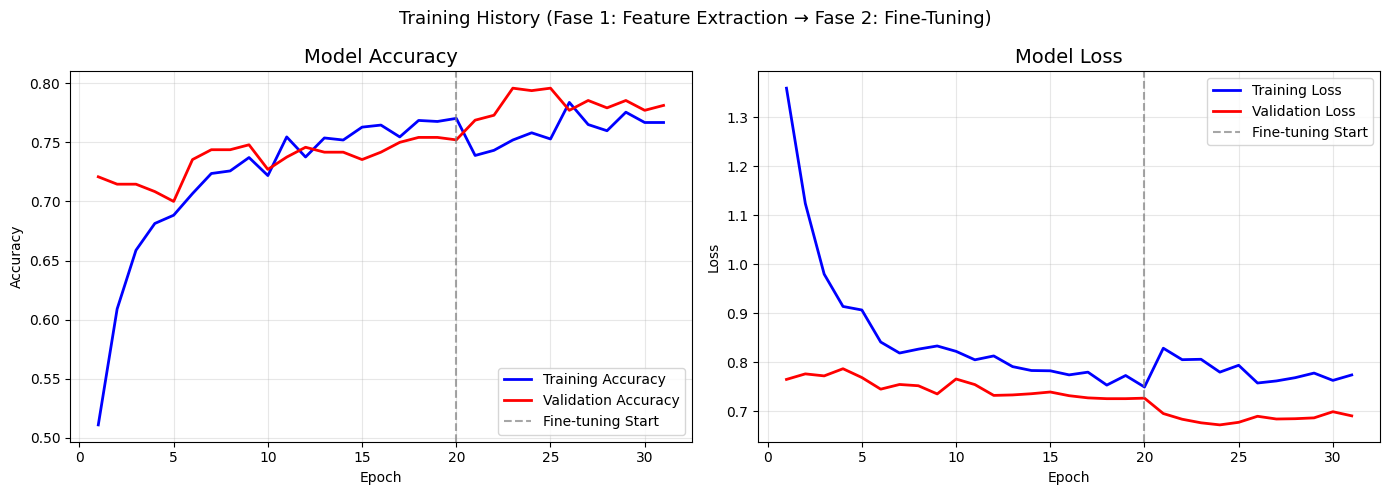

In [125]:
def plot_training_history(history1, history2, save_path='training_history.png'):
    """Plot gabungan training history dari 2 fase."""
    # Gabungkan history
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)
    phase1_end = len(history1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    ax1.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
    ax1.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    ax1.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
    ax2.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
    ax2.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Training History (Fase 1: Feature Extraction → Fase 2: Fine-Tuning)', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_phase1, history_phase2)

## 16. Evaluasi pada Test Set

In [126]:
print("=" * 60)
print("EVALUASI PADA TEST SET")
print("=" * 60)

# Buat test generator baru untuk evaluasi
test_gen_eval = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=categories,
    shuffle=False
)

# Evaluasi keseluruhan
test_loss, test_accuracy = model.evaluate(test_gen_eval, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

EVALUASI PADA TEST SET
Found 494 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/16 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7990 - loss: 0.6666

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8016 - loss: 0.6614

Test Loss:     0.6614
Test Accuracy: 0.8016 (80.16%)


In [127]:
# Prediksi untuk classification report & confusion matrix
test_gen_eval.reset()
y_pred_proba = model.predict(test_gen_eval, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen_eval.classes

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# Per-class accuracy
print("=== Akurasi Per Kelas ===")
cm = confusion_matrix(y_true, y_pred)
for i, name in enumerate(class_names):
    cls_total = cm[i].sum()
    cls_correct = cm[i, i]
    cls_acc = cls_correct / cls_total if cls_total > 0 else 0
    print(f"  {name}: {cls_acc*100:.2f}% ({cls_correct}/{cls_total})")

16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step

=== Classification Report ===
              precision    recall  f1-score   support

     Organik       0.94      0.82      0.88       299
   Anorganik       0.66      0.86      0.74        98
      Residu       0.63      0.68      0.65        97

    accuracy                           0.80       494
   macro avg       0.74      0.79      0.76       494
weighted avg       0.82      0.80      0.81       494

=== Akurasi Per Kelas ===
  Organik: 82.27% (246/299)
  Anorganik: 85.71% (84/98)
  Residu: 68.04% (66/97)


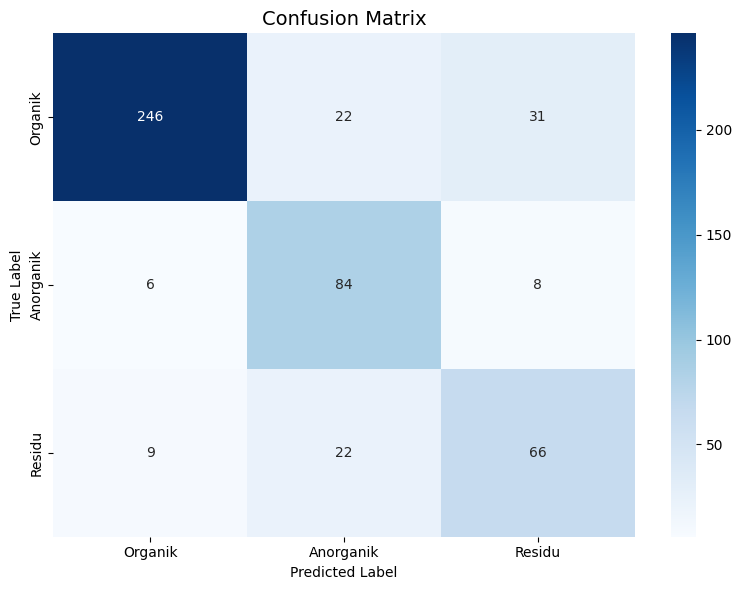

In [128]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

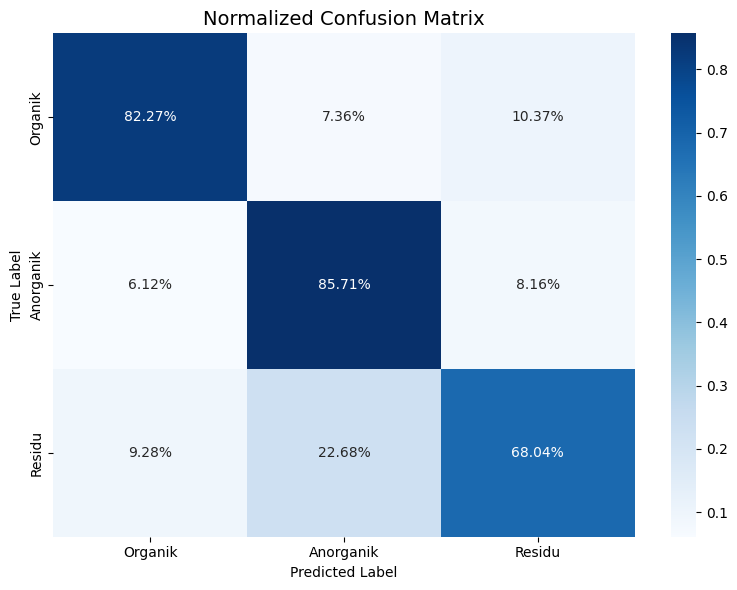

In [129]:
# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Evaluasi dengan Test-Time Augmentation (TTA)

TTA: prediksi gambar test sebanyak beberapa kali dengan augmentasi ringan,
lalu rata-ratakan hasilnya. Biasanya meningkatkan akurasi 1-3%.

In [130]:
print("=" * 60)
print("EVALUASI DENGAN TEST-TIME AUGMENTATION (TTA)")
print("=" * 60)

# Augmentasi ringan untuk TTA
tta_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

NUM_TTA = 5

def evaluate_with_tta(model, dataframe, num_tta=NUM_TTA):
    """Evaluasi model dengan Test-Time Augmentation."""
    all_preds = []

    # Prediksi 1: gambar asli (tanpa augmentasi)
    print("TTA 0/{num_tta}: Prediksi gambar asli...")
    gen_original = val_test_datagen.flow_from_dataframe(
        dataframe=dataframe, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=categories, shuffle=False
    )
    preds = model.predict(gen_original, verbose=1)
    all_preds.append(preds)

    # Prediksi 2-6: gambar ter-augmentasi
    for i in range(num_tta):
        print(f"TTA {i+1}/{num_tta}: Prediksi gambar ter-augmentasi...")
        gen_tta = tta_datagen.flow_from_dataframe(
            dataframe=dataframe, x_col='filename', y_col='class',
            target_size=IMG_SIZE, batch_size=BATCH_SIZE,
            class_mode='categorical', classes=categories, shuffle=False
        )
        preds = model.predict(gen_tta, verbose=1)
        all_preds.append(preds)

    # Rata-rata dari semua prediksi
    mean_preds = np.mean(all_preds, axis=0)
    return np.argmax(mean_preds, axis=1)

y_pred_tta = evaluate_with_tta(model, test_df)

EVALUASI DENGAN TEST-TIME AUGMENTATION (TTA)
TTA 0/{num_tta}: Prediksi gambar asli...
Found 494 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/16 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
TTA 1/5: Prediksi gambar ter-augmentasi...
Found 494 validated image filenames belonging to 3 classes.


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
TTA 5/5: Prediksi gambar ter-augmentasi...
Found 494 validated image filenames belonging to 3 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/16 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


In [131]:
# Hasil TTA
print("\n=== Classification Report (dengan TTA) ===")
print(classification_report(y_true, y_pred_tta, target_names=class_names))

tta_accuracy = accuracy_score(y_true, y_pred_tta)
print(f"Overall TTA Accuracy: {tta_accuracy*100:.2f}%")
print(f"Peningkatan dari standar: {(tta_accuracy - test_accuracy)*100:+.2f}%")

# Per-class accuracy dengan TTA
print("\n=== Akurasi Per Kelas (dengan TTA) ===")
cm_tta = confusion_matrix(y_true, y_pred_tta)
for i, name in enumerate(class_names):
    cls_total = cm_tta[i].sum()
    cls_correct = cm_tta[i, i]
    cls_acc = cls_correct / cls_total if cls_total > 0 else 0
    print(f"  {name}: {cls_acc*100:.2f}% ({cls_correct}/{cls_total})")


=== Classification Report (dengan TTA) ===
              precision    recall  f1-score   support

     Organik       0.93      0.87      0.90       299
   Anorganik       0.68      0.82      0.74        98
      Residu       0.66      0.66      0.66        97

    accuracy                           0.82       494
   macro avg       0.76      0.78      0.77       494
weighted avg       0.83      0.82      0.82       494

Overall TTA Accuracy: 81.78%
Peningkatan dari standar: +1.62%

=== Akurasi Per Kelas (dengan TTA) ===
  Organik: 86.96% (260/299)
  Anorganik: 81.63% (80/98)
  Residu: 65.98% (64/97)


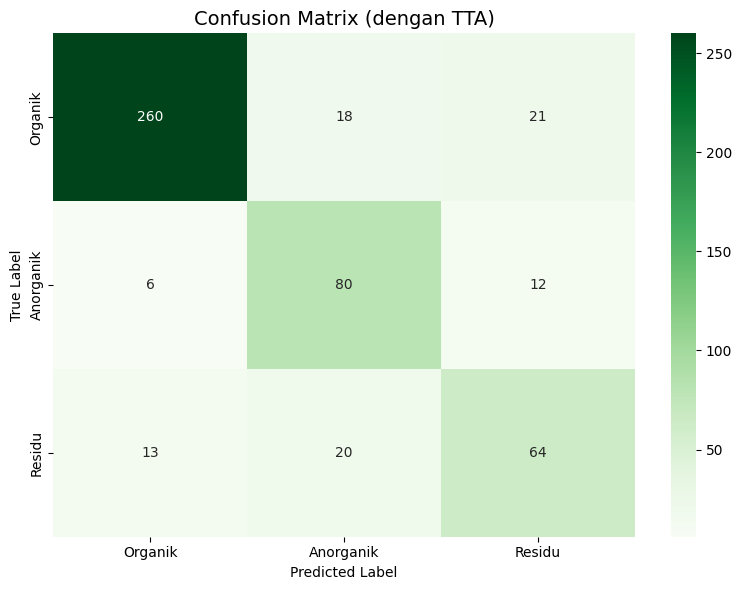

In [132]:
# Confusion Matrix TTA
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (dengan TTA)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_tta.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Visualisasi Prediksi

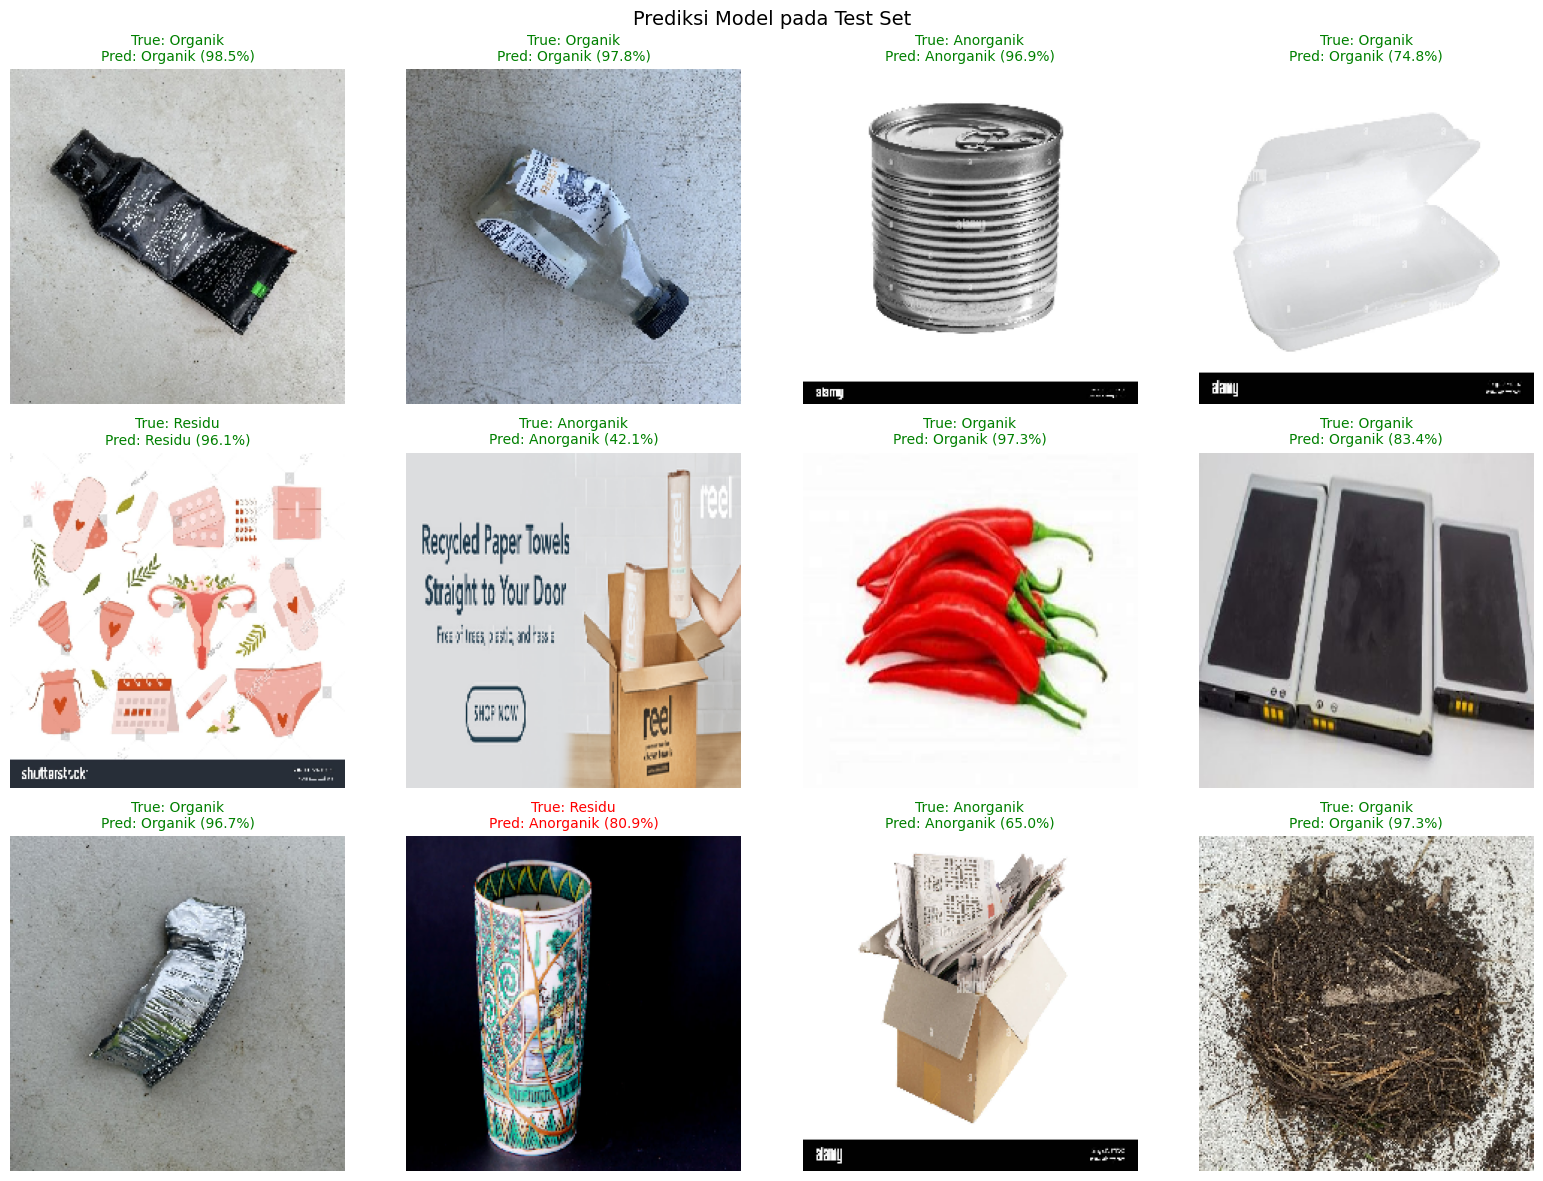

In [133]:
def show_predictions(dataframe, model, class_names, n_samples=12):
    """Tampilkan gambar dengan prediksi dan label asli."""
    sample = dataframe.sample(n=min(n_samples, len(dataframe)), random_state=SEED)

    cols = 4
    rows = (len(sample) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i, (_, row) in enumerate(sample.iterrows()):
        ax = axes[i]
        try:
            img = load_img(row['filename'], target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0
            img_batch = np.expand_dims(img_array, axis=0)

            predictions = model.predict(img_batch, verbose=0)
            pred_idx = np.argmax(predictions[0])
            pred_label = class_names[pred_idx]
            true_label = row['class']
            confidence = predictions[0][pred_idx] * 100

            ax.imshow(img)
            color = 'green' if pred_label == true_label else 'red'
            ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                         color=color, fontsize=10)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center')
        ax.axis('off')

    # Hide unused axes
    for i in range(len(sample), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Prediksi Model pada Test Set', fontsize=14)
    plt.tight_layout()
    plt.savefig('prediksi_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(test_df, model, class_names)

## 19. Save Model Final

In [134]:
# Save model dalam format Keras
model.save('waste_classifier_organik_anorganik_residu.keras')
print("Model tersimpan: waste_classifier_organik_anorganik_residu.keras")

# Save juga dalam format TFLite (untuk deployment mobile)
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()

    tflite_path = 'waste_classifier.tflite'
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"Model TFLite tersimpan: {tflite_path} ({len(tflite_model) / 1024 / 1024:.1f} MB)")
except Exception as e:
    print(f"Gagal mengonversi ke TFLite: {e}")

# Save class names
class_info = {
    'class_names': class_names,
    'class_indices': train_generator.class_indices,
    'img_size': list(IMG_SIZE),
    'model_architecture': 'MobileNetV2 (Transfer Learning v2)',
    'improvements': [
        'Hybrid Balancing (Organik downsample ke 2000)',
        'MobileNetV2 + Enhanced Head (BatchNorm, Dense 512→256)',
        'MixUp Augmentation (alpha=0.2)',
        'Label Smoothing (0.1)',
        'Class Weights (balanced)',
        'Augmentasi agresif (rotation 40, vertical flip, channel shift)',
        'CosineDecay LR schedule',
        'Test-Time Augmentation (TTA)'
    ]
}
with open('class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)
print("Class info tersimpan: class_info.json")

Model tersimpan: waste_classifier_organik_anorganik_residu.keras
INFO:tensorflow:Assets written to: C:\Users\Bisma\AppData\Local\Temp\tmpq3z51anb\assets


INFO:tensorflow:Assets written to: C:\Users\Bisma\AppData\Local\Temp\tmpq3z51anb\assets


Saved artifact at 'C:\Users\Bisma\AppData\Local\Temp\tmpq3z51anb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_807')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1387003420816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957148560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957147408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957144720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957145104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957146064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957151632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957147600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957144144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386957151440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

## 20. Fungsi Prediksi untuk Gambar Baru

In [135]:
def predict_waste(image_path, model=model, class_names=class_names, img_size=IMG_SIZE):
    """Prediksi kategori sampah dari path gambar."""
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(img_size, Image.LANCZOS)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100

    # Tampilkan hasil
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img)
    ax1.set_title(f"Prediksi: {class_names[pred_idx]}\n({confidence:.1f}%)",
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    colors = ['#2ecc71' if i == pred_idx else '#bdc3c7' for i in range(len(class_names))]
    bars = ax2.barh(class_names, predictions[0] * 100, color=colors)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Probabilitas per Kelas')
    ax2.set_xlim(0, 100)

    for bar, val in zip(bars, predictions[0] * 100):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    return class_names[pred_idx], confidence

# Contoh penggunaan (uncomment dan ganti path):
# result, conf = predict_waste("path/ke/gambar/sampah.jpg")
# print(f"Hasil: {result} ({conf:.1f}%)")

## Ringkasan Perbaikan (v1 → v2)

| Aspek | v1 (78% accuracy) | v2 (improved) |
|-------|-------------------|---------------|
| **Data** | Undersample semua ke 647 (~1941 total) | Hybrid: Organik→2000, keep all lainnya (~3300) + class_weight |
| **Base Model** | MobileNetV2 | MobileNetV2 + **Enhanced Head** |
| **Head** | Dense 256→128→3 | Dense 512→256→3 + **BatchNormalization** |
| **Loss** | CrossEntropy | CrossEntropy + Label Smoothing 0.1 |
| **Augmentasi** | Rotation 30°, brightness 0.8-1.2 | Rotation 40°, brightness 0.6-1.4, vertical flip, channel shift |
| **MixUp** | ❌ | ✅ (alpha=0.2) |
| **Class Weight** | ❌ | ✅ (balanced) |
| **Training** | 15+15 epoch, fixed LR | 20+30 epoch, CosineDecay LR |
| **Fine-tune** | 30 layers | 50 layers |
| **TTA** | ❌ | ✅ (5 augmented predictions) |